Determine frequency ranges to identify the oscillation motif  
This is composed of two steps:  
1. Fit the PSD curves by Cacuhy distribution (empirically, Cachy distribution was best fitted)  
2. Identify the frequency range  

In [1]:
from scipy.optimize import curve_fit
import matplotlib.pyplot as plt
import numpy as np

from pytools import hhtools
from pytools import oscdetector as od

import os


def read_current_time():
    from datetime import datetime
    now = datetime.now()

    return "%d%02d%02d-%02d:%02d:%02d"%(now.year, now.month, now.day,
                                        now.hour, now.minute, now.second)


def f_cauchy(x, a0, b0, x0, g0):
    return a0/np.pi*(g0/((x-x0)**2+g0**2)) + b0

def f_cauchy2(x, a0, b0, x0, g0, a1, b1, x1, g1):
    y0 = f_cauchy(x, a0, b0, x0, g0)
    y1 = f_cauchy(x, a1, b1, x1, g1)
    return y0 + y1

def fit_distrib(x, y, init_point, bound_point):
    key_init_set = ("a0", "b0", "f0", "g0")
    key_bound_set = ("ab", "bb", "fb", "gb")
    if len(init_point["a0"]) == 1:
        p0 = [init_point[k][0] for k in key_init_set]
        bmin = [bound_point[k][0][0] for k in key_bound_set]
        bmax = [bound_point[k][0][1] for k in key_bound_set]
        params, _ = curve_fit(f_cauchy, x, y, p0=p0, bounds=(bmin, bmax))
        
    elif len(init_point["a0"]) == 2:
        p0, bmin, bmax = [], [], []
        for n in range(2):
            p0.extend([init_point[k][n] for k in key_init_set])
            bmin.extend([bound_point[k][n][0] for k in key_bound_set])
            bmax.extend([bound_point[k][n][1] for k in key_bound_set])
        params, _ = curve_fit(f_cauchy2, x, y, p0=p0, bounds=(bmin, bmax))
        
    else:
        raise ValueError("Unexpected # of init vars")
    
    return params


In [ ]:
tag = ""
# summary_obj = hhtools.SummaryLoader("../gen_three_pop_samples_repr/data"+tag, load_only_control=True)
summary_obj = hhtools.SummaryLoader("../results/twopop_output/data"+tag, load_only_control=True)

srate = 2000

amp_range_set = [[] for _ in range(summary_obj.num_controls[0])]
save_path ="./data/osc_motif" + tag

print(summary_obj.num_controls[0])
print(summary_obj.controls)

10
{'cluster_id': [1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, -1.0, -2.0, -3.0]}


Identify the frequency ranges (manually)

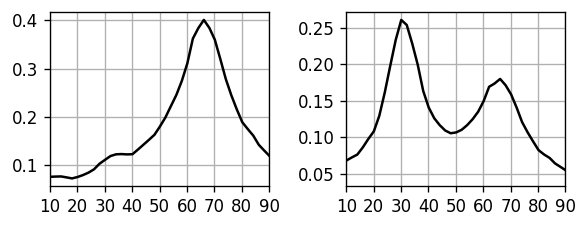

In [9]:
cid = 5

yf = [0, 0]
ntrial = 20
for n in range(ntrial):
    detail_data = summary_obj.load_detail(cid-1, n)
    psd_set, fpsd, tpsd = od.compute_stfft_all(detail_data, frange=(10, 100), mbin_t=0.01, wbin_t=0.5, srate=srate)
    yf[0] += psd_set[1].mean(axis=1)
    yf[1] += psd_set[2].mean(axis=1)
    
yf[0] /= ntrial
yf[1] /= ntrial

plt.figure(figsize=(5, 2), dpi=120)
for n in range(2):
    plt.subplot(1,2,n+1)
    plt.plot(fpsd, yf[n], c='k')
    plt.xticks(np.arange(10, 100, 10))
    plt.grid(True)
    plt.xlim([10, 90])

plt.tight_layout()
plt.show()

In [ ]:
# set initial parameters (Select regime ID)

#  # Regime 1
# init_point = [dict(a0=[0.1, 0.1], b0=[0, 0], f0=[25, 40], g0=[10, 10]),
#               dict(a0=[5], b0=[0], f0=[25], g0=[10])]
# bound_point = [dict(ab=[[0, 10], [0.05, 10]], bb=[[0, 10], [0, 10]], fb=[[20, 35], [35, 50]], gb=[[0, 50], [0, 50]]),
#                dict(ab=[[0, 10]], bb=[[0, 10]], fb=[[10, 40]], gb=[[0, 50]])]

# # Regime 2
# init_point = [dict(a0=[5], b0=[0], f0=[40], g0=[10]),
#               dict(a0=[5], b0=[0], f0=[40], g0=[10])]
# bound_point = [dict(ab=[[0, 10]], bb=[[0, 10]], fb=[[10, 40]], gb=[[0, 50]]),
#                dict(ab=[[0, 10]], bb=[[0, 10]], fb=[[10, 40]], gb=[[0, 50]])]

# # Regime 3
# init_point = [dict(a0=[5, 5], b0=[0, 0], f0=[35, 65], g0=[10, 10]),
#               dict(a0=[5, 5], b0=[0, 0], f0=[35, 65], g0=[10, 10])]
# bound_point = [dict(ab=[[0, 10], [0, 10]], bb=[[0, 10], [0, 10]], fb=[[10, 45], [50, 80]], gb=[[0, 50], [0, 50]]),
#                dict(ab=[[0, 10], [0, 10]], bb=[[0, 10], [0, 10]], fb=[[10, 45], [50, 80]], gb=[[0, 50], [0, 50]])]

# # Regime 4
# init_point = [dict(a0=[5, 5], b0=[0, 0], f0=[35, 65], g0=[10, 10]),
#               dict(a0=[5, 5], b0=[0, 0], f0=[35, 65], g0=[10, 10])]
# bound_point = [dict(ab=[[0, 10], [0, 10]], bb=[[0, 10], [0, 10]], fb=[[10, 45], [50, 80]], gb=[[0, 50], [0, 50]]),
#                dict(ab=[[0, 10], [0, 10]], bb=[[0, 10], [0, 10]], fb=[[10, 45], [50, 80]], gb=[[0, 50], [0, 50]])]

# # Regime 5
init_point = [dict(a0=[5], b0=[0], f0=[65], g0=[10]),
              dict(a0=[5, 5], b0=[0, 0], f0=[30, 65], g0=[10, 10])]
bound_point = [dict(ab=[[0, 10]], bb=[[0, 10]], fb=[[50, 80]], gb=[[0, 50]]),
               dict(ab=[[0, 10], [0, 10]], bb=[[0, 10], [0, 10]], fb=[[10, 40], [50, 80]], gb=[[0, 50], [0, 50]])]

# # Regime 6
# init_point = [dict(a0=[5], b0=[0], f0=[65], g0=[10]),
#               dict(a0=[5], b0=[0], f0=[65], g0=[10])]
# bound_point = [dict(ab=[[0, 10]], bb=[[0, 10]], fb=[[50, 80]], gb=[[0, 50]]),
#                dict(ab=[[0, 10]], bb=[[0, 10]], fb=[[50, 80]], gb=[[0, 50]])]

# # Regime 7 -> disconnected, echelon = 0
# init_point = [dict(a0=[5, 5], b0=[0, 0], f0=[25, 65], g0=[10, 10]),
#               dict(a0=[5, 5], b0=[0, 0], f0=[25, 65], g0=[10, 10])]
# bound_point = [dict(ab=[[0, 20], [0, 20]], bb=[[0, 10], [0, 10]], fb=[[0, 45], [50, 80]], gb=[[0, 50], [0, 50]]),
#                dict(ab=[[0, 20], [0, 20]], bb=[[0, 10], [0, 10]], fb=[[0, 45], [50, 80]], gb=[[0, 50], [0, 50]])]

# # Regime 8 -> disconnected, echelon = 0.5
# init_point = [dict(a0=[5], b0=[0], f0=[35], g0=[10]),
#               dict(a0=[5], b0=[0], f0=[35], g0=[10])]
# bound_point = [dict(ab=[[0, 10]], bb=[[0, 10]], fb=[[10, 80]], gb=[[0, 50]]),
#                dict(ab=[[0, 10]], bb=[[0, 10]], fb=[[10, 80]], gb=[[0, 50]])]

# # Regime 9 -> disconnected, echelon = 1
# init_point = [dict(a0=[5], b0=[0], f0=[35], g0=[10]),
#               dict(a0=[5], b0=[0], f0=[35], g0=[10])]
# bound_point = [dict(ab=[[0, 10]], bb=[[0, 10]], fb=[[10, 80]], gb=[[0, 50]]),
#                dict(ab=[[0, 10]], bb=[[0, 10]], fb=[[10, 80]], gb=[[0, 50]])]



[10.          0.07969176 66.04449799  9.93743673]
[5.35376148e+00 1.54688069e-02 3.08777925e+01 7.85484764e+00
 4.55721576e+00 1.54670907e-02 6.57901556e+01 1.05451780e+01]


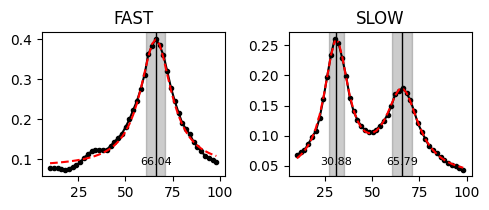

{'fpop': [[], array([61.08, 71.01])], 'spop': [array([26.95, 34.81]), array([60.52, 71.06])]}


In [13]:
c = 0.5
keys = ("fpop", "spop")
amp_range = dict()

fig, axs = plt.subplots(1,2,figsize=(5, 2.2))
for n in range(2):
    ax = axs[n]
    ax.plot(fpsd, yf[n], 'k.-')
    pfit = fit_distrib(fpsd, yf[n], init_point[n], bound_point[n])
    print(pfit)
    
    amp_range[keys[n]] = [[], []]
    yl = ax.get_ylim()
    y0 = yl[0] + (yl[1]-yl[0])/10
    
    if len(pfit)//4 == 1:
        ax.plot(fpsd, f_cauchy(fpsd, *pfit), 'r--')
        fl = np.round((pfit[2]-c*pfit[3], pfit[2]+c*pfit[3]), 2)
        ax.fill_betweenx(yl, fl[0], fl[1], color='k', alpha=0.2)
        amp_range[keys[n]][1-n] = fl
        ax.vlines(pfit[2], yl[0], yl[1], color='k', linewidth=1)
        ax.text(pfit[2], y0, "%.2f"%(pfit[2]), fontsize=8, va="center", ha="center")
        
    if len(pfit)//4 == 2:
        ax.plot(fpsd, f_cauchy2(fpsd, *pfit), 'r--')
        fl = np.round((pfit[2]-c*pfit[3], pfit[2]+c*pfit[3]), 2)
        ax.fill_betweenx(yl, fl[0], fl[1], color='k', alpha=0.2)
        amp_range[keys[n]][0] = fl
        ax.vlines(pfit[2], yl[0], yl[1], color='k', linewidth=1)
        ax.text(pfit[2], y0, "%.2f"%(pfit[2]), fontsize=8, va="center", ha="center")
        
        fl = np.round((pfit[6]-c*pfit[7], pfit[6]+c*pfit[7]), 2)
        ax.fill_betweenx(yl, fl[0], fl[1], color='k', alpha=0.2)
        amp_range[keys[n]][1] = fl
        ax.vlines(pfit[6], yl[0], yl[1], color='k', linewidth=1)
        ax.text(pfit[6], y0, "%.2f"%(pfit[6]), fontsize=8, va="center", ha="center")

    ax.set_ylim(yl)
    
# plt.suptitle("CID = %d"%(cid), fontsize=14)
axs[0].set_title("FAST", fontsize=12)
axs[1].set_title("SLOW", fontsize=12)
plt.tight_layout()
plt.savefig(os.path.join(save_path, "cid_%d.png"%(cid)), bbox_inches="tight", dpi=200)

plt.show()
print(amp_range)

amp_range_set[cid-1] = amp_range

In [ ]:
for nc in range(len(amp_range_set)):
    for pname in ("fpop", "spop"):
        if len(amp_range_set[nc][pname][1]) == 0:
            amp_range_set[nc][pname][1], amp_range_set[nc][pname][0] = amp_range_set[nc][pname][0], amp_range_set[nc][pname][1]

In [116]:
key_names = ("fpop", "spop")

import pickle as pkl

fname = os.path.join(save_path, "amp_range_set.pkl")
with open(fname, "wb") as fp:
    pkl.dump({"amp_range_set": amp_range_set,
              "source_dir": summary_obj.fdir,
              "last-updated": read_current_time()}, fp)
    
# frequency range are determined based on fourier transform result